# 1. Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 2. System Parameters

In [ ]:
fc = 3.5e9                                                  # 3.5 GHz (5G candidate band)
c = 3e8                                                     # Speed of light
wavelength = c / fc                                         # Lambda = c/f
alpha = 2                                                   # Path loss exponent (free space)
K = 5                                                       # Rician factor
Pt = 1                                                      # Transmit power (normalized)
noise_power = 1e-9 * (1 + 0.1*np.random.randn())            # Noise power
N = 1024                                                     # Number of IRS elements

# 3. OBSTACLES

In [ ]:
# ----- Buildings --------
blocks = [(10,40,-90,-60), (60,90,-90,-60), (-40,-10,-90,-60), (-90,-60,-90,-60),
          (10,40,-40,-10), (60,90,-40,-10), (-40,-10,-40,-10), (-90,-60,-40,-10),
          (10,40,10,40), (60,90,10,40), (-40,-10,10,40), (-90,-60,10,40),
          (10,40,60,90), (60,90,60,90), (-40,-10,60,90), (-90,-60,60,90),]

# ----- Roads ------
city_limit = 50
road_width = 20
roads_x = [-100, -50, 0, 50, 100]
roads_y = [-100, -50, 0, 50, 100]
junctions = [(x, y) for x in roads_x for y in roads_y]

# 4. Obstacle Formula

In [ ]:
def is_blocked(p1, p2):

    for (x_min, x_max, y_min, y_max) in blocks:

        # Check line intersection using sampling (simple & robust)
        for t in np.linspace(0, 1, 20):
            point = p1 + t * (p2 - p1)

            if (x_min <= point[0] <= x_max) and (y_min <= point[1] <= y_max):
                return True

    return False

In [ ]:
def is_inside_block(point):
    for (x_min, x_max, y_min, y_max) in blocks:
        if x_min <= point[0] <= x_max and y_min <= point[1] <= y_max:
            return True
    return False

In [ ]:
def is_on_road(pos):
    x, y = pos

    for rx in roads_x:
        if abs(x - rx) <= road_width/2:
            return True

    for ry in roads_y:
        if abs(y - ry) <= road_width/2:
            return True

    return False

In [ ]:
def snap_to_road(pos):
    x, y = pos

    nearest_x = min(roads_x, key=lambda r: abs(r - x))
    nearest_y = min(roads_y, key=lambda r: abs(r - y))

    if abs(x - nearest_x) < abs(y - nearest_y):
        x = nearest_x + np.random.uniform(-road_width/2, road_width/2)
    else:
        y = nearest_y + np.random.uniform(-road_width/2, road_width/2)

    return np.array([x, y])

# 5. 2D Positions

In [ ]:
BS = np.array([0, 0])         # Base station at origin
IRS = np.array([50, 0])       # IRS placed 50m away on x-axis
irs_positions = [
    np.array([-50, 0]),
    np.array([50, 0]),
    np.array([0, 50]),
    np.array([0, -50])
]

# ---------------- MULTI USER SETUP ----------------
num_users = 2

users = []

for _ in range(num_users):

    start = np.array(
        junctions[np.random.randint(len(junctions))]
    ).astype(float)

    user = {

        "pos": start.copy(),

        "velocity": np.zeros(2),

        "target": start.copy(),

        "prev_target": None,

        "trajectory": [],

        "measurement_x": [],
        "measurement_y": [],

        "snr_no_list": [],
        "snr_with_list": []
    }

    users.append(user)

# 6. Distance Formula

In [ ]:
def Distance(p1, p2):
    return np.linalg.norm(p1 - p2)

# 7. Channel Model (RICIAN FADING)

In [ ]:
def channel(p1,p2):
    d = Distance(p1, p2)
    blocked = is_blocked(p1, p2)
    # LOS
    los = np.exp(-1j * 2 * np.pi * d / wavelength)

    # NLOS
    nlos = (np.random.randn() + 1j*np.random.randn()) / np.sqrt(2)

    if blocked:
        #No LOS
        h = nlos
    else:
        # Rician fading
        h = np.sqrt(K/(K+1)) * los + np.sqrt(1/(K+1)) * nlos

    return h / (d**alpha)

# 8. User Mobility Parameters

In [ ]:
dt = 0.05
T = 200
beta = 0.9          # Gauss-Markov smoothness
speed_mean = 5.0    # m/s
circle_radius = 100  # Boundary radius
circle_center = BS.copy()

# 9. Mobility Function

In [ ]:
def update_user(user):

    direction_vec = user["target"] - user["pos"]

    distance = np.linalg.norm(direction_vec)

    speed = 5

    if distance > 5:

        direction_vec = direction_vec / (distance + 1e-6)

        user["velocity"] = direction_vec * speed

        user["pos"] = user["pos"] + user["velocity"] * dt

    else:

        x = min(roads_x, key=lambda r: abs(r - user["target"][0]))
        y = min(roads_y, key=lambda r: abs(r - user["target"][1]))

        neighbors = []

        ix = roads_x.index(x)
        iy = roads_y.index(y)

        if ix+1 < len(roads_x):
            neighbors.append((roads_x[ix+1], y))

        if ix-1 >= 0:
            neighbors.append((roads_x[ix-1], y))

        if iy+1 < len(roads_y):
            neighbors.append((x, roads_y[iy+1]))

        if iy-1 >= 0:
            neighbors.append((x, roads_y[iy-1]))

        if user["prev_target"] is not None:

            neighbors = [
                n for n in neighbors
                if not np.all(np.array(n) == user["prev_target"])
            ]

        if len(neighbors) == 0:

            user["target"] = np.array(
                junctions[np.random.randint(len(junctions))]
            )

        else:

            user["prev_target"] = user["target"].copy()

            user["target"] = np.array(
                neighbors[np.random.randint(len(neighbors))]
            )

    # road correction
    if not is_on_road(user["pos"]):

        user["pos"] = snap_to_road(user["pos"])

# 10. Storage

In [ ]:
trajectory = []
SNR_no_IRS_list = []
SNR_with_IRS_list = []

# 11. Time Simulation

In [ ]:
trajectory = []
SNR_no_IRS_list = []
SNR_with_IRS_list = []


for t in range(T):

    for user in users:

        # ---------------- MOBILITY ----------------
        update_user(user)

        User = user["pos"]

        user["trajectory"].append(User.copy())

        # ---------------- CHANNEL ----------------
        d_BU = Distance(BS, User)

        h_d = channel(BS, User)

        h_IRS_total = 0

        for IRS in irs_positions:

            d_BR = np.linalg.norm(BS - IRS)

            h_br_scalar = (
                (1 / (d_BR**alpha))
                * np.exp(-1j * 2 * np.pi * d_BR / wavelength)
            )

            d_RU = np.linalg.norm(IRS - User)

            h_ru_scalar = (
                (1 / (d_RU**alpha))
                * np.exp(-1j * 2 * np.pi * d_RU / wavelength)
            )

            h_br = np.ones(N) * h_br_scalar
            h_ru = np.ones(N) * h_ru_scalar

            a = np.conj(h_ru) * h_br

            theta_opt = np.angle(h_d) - np.angle(a)

            Phi = np.exp(1j * theta_opt)

            h_IRS = np.sum(a * Phi)

            h_IRS_total += h_IRS

        # ---------------- SNR ----------------
        SNR_no_IRS = Pt * np.abs(h_d)**2 / noise_power

        h_total = h_d + h_IRS_total

        SNR_with_IRS = Pt * np.abs(h_total)**2 / noise_power

        # store
        user["snr_no_list"].append(
            10*np.log10(SNR_no_IRS)
        )

        user["snr_with_list"].append(
            10*np.log10(SNR_with_IRS)
        )

trajectory = np.array(trajectory)

# 12. Live plotting setup

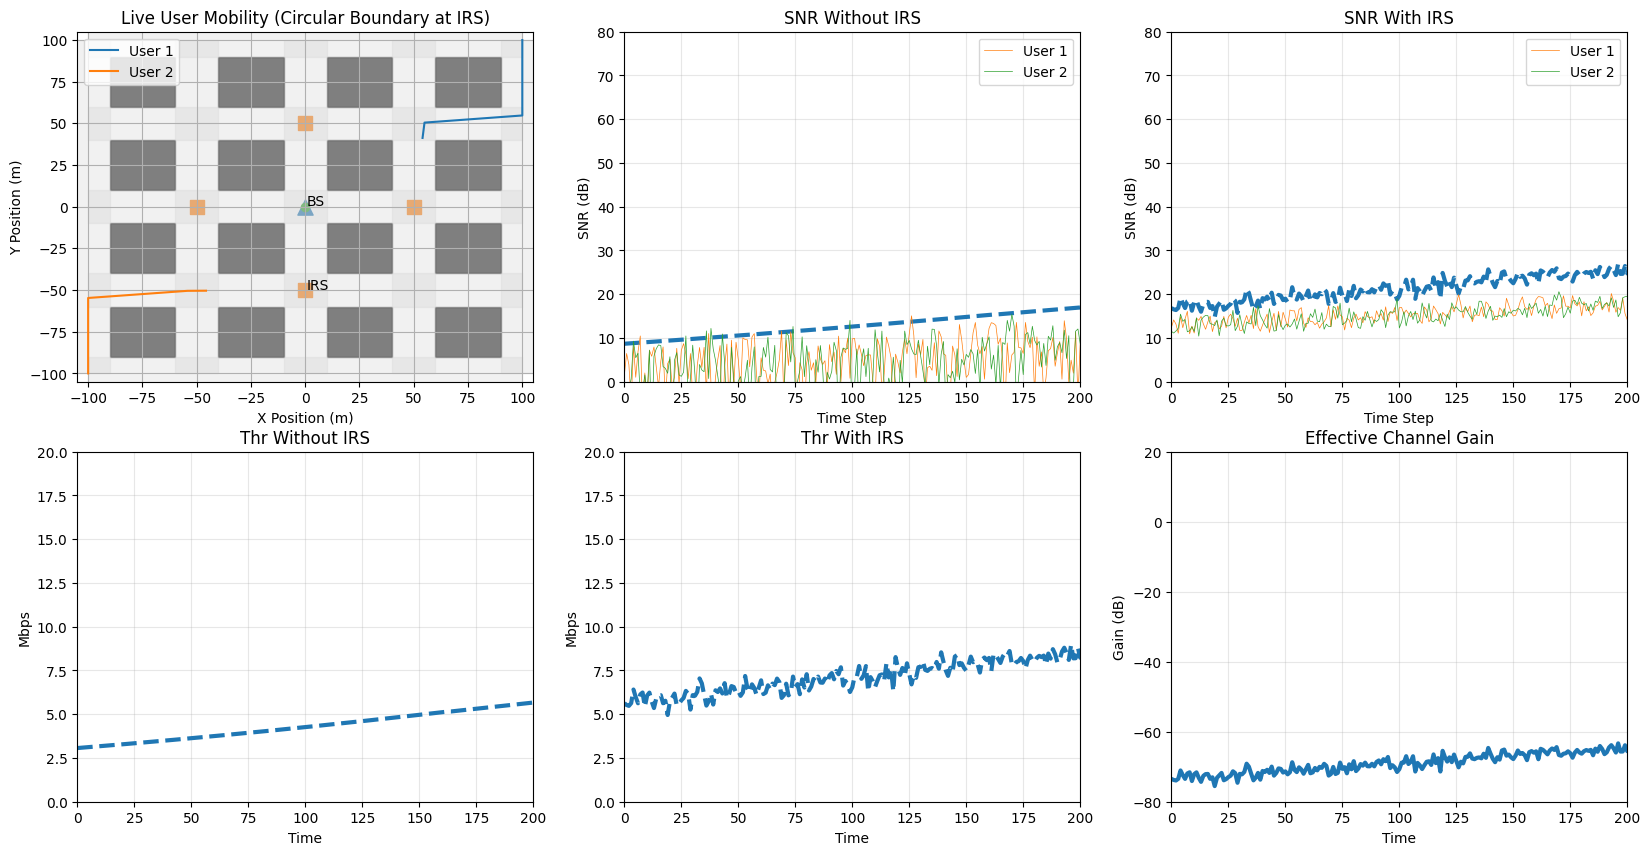

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20,10))
(ax, ax_snr_no, ax_snr_with, ax_thr_no, ax_thr_with, ax_gain) = axes.flatten()

user_lines = []
snr_lines_no = []
snr_lines_with = []
mean_snr_no_list = []
mean_snr_with_list = []
mean_thr_no_list = []
mean_thr_with_list = []
channel_gain_list = []

# ----- Measurements -----
measurement_x = []
measurement_y = []

# ---- BS & IRS Plot ----
bs_point = ax.scatter(BS[0], BS[1], marker='^', s=120)
irs_x = [pos[0] for pos in irs_positions]
irs_y = [pos[1] for pos in irs_positions]

ax.scatter(irs_x, irs_y, marker='s', s=100)

# ---- Labels ----
ax.text(BS[0] + 0.5, BS[1] + 0.5, 'BS', fontsize=10)
ax.text(IRS[0] + 0.5, IRS[1] + 0.5, 'IRS', fontsize=10)

# ---------------- MULTI USER PLOTS ----------------
mean_snr_no_line, = ax_snr_no.plot([], [],linewidth=3,linestyle='--',label='Mean SNR w/o IRS')
mean_snr_with_line, = ax_snr_with.plot([], [],linewidth=3,linestyle='--',label='Mean SNR w/ IRS')

thr_no_line, = ax_thr_no.plot( [], [], linewidth=3, linestyle='--', label='Mean Throughput w/o IRS')
thr_with_line, = ax_thr_with.plot( [], [], linewidth=3, linestyle='--', label='Mean Throughput w/ IRS')

gain_line, = ax_gain.plot( [], [], linewidth=3)

for i in range(num_users):
    line_user, = ax.plot([], [], label=f'User {i+1}')
    line_no, = ax_snr_no.plot([], [], linewidth=0.5)
    line_with, = ax_snr_with.plot([], [], linewidth=0.5)
    user_lines.append(line_user)
    snr_lines_no.append(line_no)
    snr_lines_with.append(line_with)

center_point = ax.scatter(circle_center[0], circle_center[1])

ax.set_xlim(circle_center[0] - circle_radius - 5,circle_center[0] + circle_radius + 5)
ax.set_ylim(circle_center[1] - circle_radius - 5,circle_center[1] + circle_radius + 5)
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Live User Mobility (Circular Boundary at IRS)")
ax.grid(True)
ax.legend()

for axis in [ax_snr_no, ax_snr_with]:
    axis.set_xlim(0, T)
    axis.set_ylim(0, 80)
    axis.set_xlabel("Time Step")
    axis.set_ylabel("SNR (dB)")
    axis.grid(alpha=0.3)
ax_snr_no.set_title("SNR Without IRS")
ax_snr_with.set_title("SNR With IRS")
ax_snr_no.legend([snr_lines_no[i] for i in range(num_users)],[f'User {i+1}' for i in range(num_users)])
ax_snr_with.legend([snr_lines_with[i] for i in range(num_users)],[f'User {i+1}' for i in range(num_users)])

for axis in [ax_thr_no, ax_thr_with]:
    axis.set_xlim(0, T)
    axis.set_ylim(0, 20)
    axis.set_xlabel("Time")
    axis.set_ylabel("Mbps")
    axis.grid(alpha=0.3)
ax_thr_no.set_title("Thr Without IRS")
ax_thr_with.set_title("Thr With IRS")

ax_gain.set_xlim(0, T)
ax_gain.set_ylim(-80, 20)
ax_gain.set_title("Effective Channel Gain")
ax_gain.set_xlabel("Time")
ax_gain.set_ylabel("Gain (dB)")
ax_gain.grid(alpha=0.3)

# ---- DRAW OBSTACLE BLOCKS ----
for (x_min, x_max, y_min, y_max) in blocks:
    rect = plt.Rectangle((x_min, y_min),
                         x_max - x_min,
                         y_max - y_min,
                         color='black', alpha=0.5)
    ax.add_patch(rect)

# ---- DRAW ROADS ----
for rx in roads_x:
    rect = plt.Rectangle((rx - road_width/2, -100),
                         road_width, 200,
                         color='lightgray', alpha=0.3)
    ax.add_patch(rect)

for ry in roads_y:
    rect = plt.Rectangle((-100, ry - road_width/2),
                         200, road_width,
                         color='lightgray', alpha=0.3)
    ax.add_patch(rect)

def update(frame):

    current_snr_no = []
    current_snr_with = []
    current_thr_no = []
    current_thr_with = []
    gains = []

    for i, user in enumerate(users):

        # ---------------- MOBILITY ----------------
        update_user(user)
        User = user["pos"]

        # ---------------- MEASUREMENT ----------------
        measurement = User + np.random.normal(0, 0.5, 2)
        user["measurement_x"].append(measurement[0])
        user["measurement_y"].append(measurement[1])

        # ---------------- STORE TRAJECTORY ----------------
        user["trajectory"].append(User.copy())
        traj = np.array(user["trajectory"])
        user_lines[i].set_data(traj[:,0],traj[:,1])

        # ---------------- CHANNEL ----------------
        d_BU = max(np.linalg.norm(BS - User),0.000001)
        h_d = (1 / (d_BU**alpha)) * np.exp(-1j * 2 * np.pi * d_BU / wavelength)
        h_IRS_total = 0

        for IRS in irs_positions:

            h_br_scalar = channel(BS, IRS)
            h_ru_scalar = channel(IRS, User)
            h_br = np.ones(N) * h_br_scalar
            h_ru = np.ones(N) * h_ru_scalar
            a = np.conj(h_ru) * h_br
            theta_opt = np.angle(h_d) - np.angle(a)
            Phi = np.exp(1j * theta_opt)
            h_IRS = np.sum(a * Phi)
            h_IRS_total += h_IRS

        # ---------------- SNR ----------------
        SNR_no = Pt * np.abs(h_d)**2 / noise_power
        h_total = h_d + h_IRS_total
        SNR_with = Pt * np.abs(h_total)**2 / noise_power

        user["snr_no_list"].append(10*np.log10(SNR_no))
        user["snr_with_list"].append(10*np.log10(SNR_with))

        current_snr_no.append(10*np.log10(SNR_no))
        current_snr_with.append(10*np.log10(SNR_with))

        # ---------- Throughput ----------

        B = 1e6

        thr_no = B * np.log2(1 + SNR_no) / 1e6

        thr_with = B * np.log2(1 + SNR_with) / 1e6

        current_thr_no.append(thr_no)

        current_thr_with.append(thr_with)

        # ---------- Channel Gain ----------

        gain = 10*np.log10(np.abs(h_total)**2 + 1e-12)

        gains.append(gain)


        # ---------------- UPDATE SNR PLOTS ----------------
        snr_lines_no[i].set_data(
            range(len(user["snr_no_list"])),
            user["snr_no_list"]
        )

        snr_lines_with[i].set_data(
            range(len(user["snr_with_list"])),
            user["snr_with_list"]
        )
    # ================= MEAN SNR =================
    mean_snr_no = np.mean(current_snr_no)
    mean_snr_with = np.mean(current_snr_with)

    mean_snr_no_list.append(mean_snr_no)
    mean_snr_with_list.append(mean_snr_with)

    mean_snr_no_line.set_data(
        range(len(mean_snr_no_list)),
        mean_snr_no_list
    )

    mean_snr_with_line.set_data(
        range(len(mean_snr_with_list)),
        mean_snr_with_list
    )

    # ================= THROUGHPUT =================

    mean_thr_no = np.mean(current_thr_no)

    mean_thr_with = np.mean(current_thr_with)

    mean_thr_no_list.append(mean_thr_no)

    mean_thr_with_list.append(mean_thr_with)

    thr_no_line.set_data(
        range(len(mean_thr_no_list)),
        mean_thr_no_list
    )

    thr_with_line.set_data(
        range(len(mean_thr_with_list)),
        mean_thr_with_list
    )

    # ================= CHANNEL GAIN =================

    mean_gain = np.mean(gains)

    channel_gain_list.append(mean_gain)

    gain_line.set_data(
        range(len(channel_gain_list)),
        channel_gain_list
    )

    return (
        user_lines
        + snr_lines_no
        + snr_lines_with
        + [mean_snr_no_line]
        + [mean_snr_with_line]
        + [thr_no_line]
        + [thr_with_line]
        + [gain_line]
    )

ani = FuncAnimation(fig, update, frames=T, interval=200)
HTML(ani.to_html5_video())

# **13. Core Prediction**

User 1
Mean Error: 1.7606190926086014 %
RMS Error: 1.7747528503025973
------------------------
User 2
Mean Error: 1.667617123106184 %
RMS Error: 1.6013650457205604
------------------------


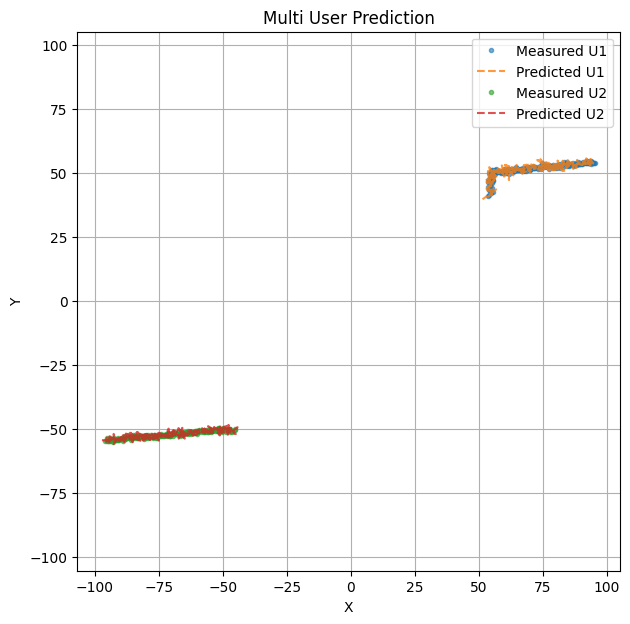

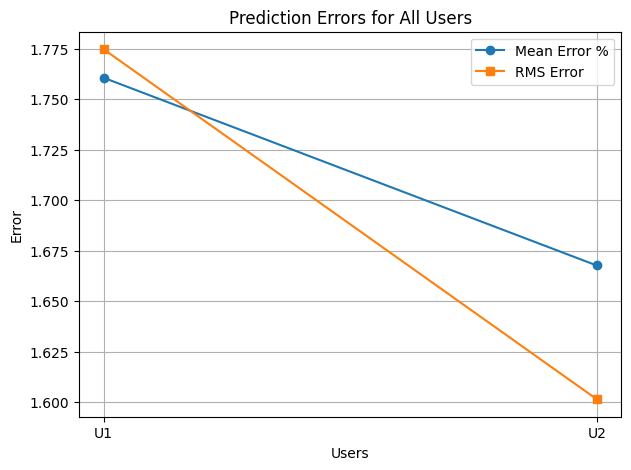

In [ ]:
# ---------------- MULTI USER PREDICTION ----------------

all_mean_errors = []

all_rms_errors = []

plt.figure(figsize=(7,7))

# ---------------- LOOP OVER USERS ----------------
for idx, user in enumerate(users):

    meas = np.column_stack((
        user["measurement_x"],
        user["measurement_y"]
    ))

    # skip if too short
    if len(meas) < 3:
        continue

    pred_list = []

    vel_list = []

    error_list = []

    perc_error_list = []

    # ---------------- PREDICTION LOOP ----------------
    for i in range(1, len(meas)-1):

        curr = meas[i]

        prev = meas[i-1]

        next_actual = meas[i+1]

        # velocity estimate
        vel = (curr - prev) / dt

        vel_list.append(vel)

        # prediction
        pred = curr + vel * dt

        pred_list.append(pred)

        # error
        err = np.linalg.norm(next_actual - pred)

        error_list.append(err)

        actual_norm = np.linalg.norm(next_actual)

        perc_error = (
            err / (actual_norm + 1e-6)
        ) * 100

        perc_error_list.append(perc_error)

    # ---------------- CONVERT ----------------
    pred_arr = np.array(pred_list)

    meas_arr = meas[1:len(pred_arr)+1]

    # ---------------- METRICS ----------------
    mean_error = np.mean(perc_error_list)

    rms_error = np.sqrt(
        np.mean(np.array(error_list)**2)
    )

    all_mean_errors.append(mean_error)

    all_rms_errors.append(rms_error)

    print(f"User {idx+1}")

    print("Mean Error:", mean_error, "%")

    print("RMS Error:", rms_error)

    print("------------------------")

    # ---------------- TRAJECTORY PLOT ----------------
    plt.plot(
        meas_arr[:,0],
        meas_arr[:,1],
        '.',
        alpha=0.6,
        label=f"Measured U{idx+1}"
    )

    plt.plot(
        pred_arr[:,0],
        pred_arr[:,1],
        '--',
        alpha=0.8,
        label=f"Predicted U{idx+1}"
    )

# ---------------- FINAL TRAJECTORY FIGURE ----------------
plt.legend()

plt.grid(True)

plt.title("Multi User Prediction")

plt.xlabel("X")

plt.ylabel("Y")

plt.axis('equal')

plt.show()

# ---------------- ERROR SUMMARY ----------------
plt.figure(figsize=(7,5))

x = np.arange(len(all_mean_errors))

plt.plot(
    x,
    all_mean_errors,
    'o-',
    label="Mean Error %"
)

plt.plot(
    x,
    all_rms_errors,
    's-',
    label="RMS Error"
)

plt.xticks(
    x,
    [f"U{i+1}" for i in range(len(all_mean_errors))]
)

plt.xlabel("Users")

plt.ylabel("Error")

plt.title("Prediction Errors for All Users")

plt.grid(True)

plt.legend()

plt.show()

# **DRL Based Agent**

# Environment

In [ ]:
class IRSEnv:
    def __init__(self):
        self.t = 0
        self.max_steps = 200

        # action grouping
        self.K = 4
        self.phase_levels = [0, np.pi/2, np.pi, 3*np.pi/2]

    def reset(self):
        global User, current_target, prev_target

        current_target = np.array(junctions[np.random.randint(len(junctions))])
        prev_target = None
        User = current_target.copy()

        self.t = 0

        return self.get_state()

    def step(self, action):
        global User, current_target, prev_target

        # ---------------- MOBILITY ----------------
        # CALL YOUR EXISTING LOGIC (copy-paste that part only)
        direction_vec = current_target - User
        distance = np.linalg.norm(direction_vec)

        if distance > 5:
            direction_vec = direction_vec / (distance + 1e-6)
            velocity = direction_vec * 5
            User = User + velocity * dt
        else:
            x = min(roads_x, key=lambda r: abs(r - current_target[0]))
            y = min(roads_y, key=lambda r: abs(r - current_target[1]))

            neighbors = []
            ix = roads_x.index(x)
            iy = roads_y.index(y)

            if ix+1 < len(roads_x):
                neighbors.append((roads_x[ix+1], y))
            if ix-1 >= 0:
                neighbors.append((roads_x[ix-1], y))
            if iy+1 < len(roads_y):
                neighbors.append((x, roads_y[iy+1]))
            if iy-1 >= 0:
                neighbors.append((x, roads_y[iy-1]))

            if prev_target is not None:
                neighbors = [n for n in neighbors if not np.all(np.array(n) == prev_target)]

            if len(neighbors) == 0:
                current_target = np.array(junctions[np.random.randint(len(junctions))])
            else:
                prev_target = current_target.copy()
                current_target = np.array(neighbors[np.random.randint(len(neighbors))])

        # ---------------- CHANNEL ----------------
        h_d = channel(BS, User)

        h_IRS_total = 0

        for IRS in irs_positions:

            h_br_scalar = channel(BS, IRS)
            h_ru_scalar = channel(IRS, User)

            h_br = np.ones(N) * h_br_scalar
            h_ru = np.ones(N) * h_ru_scalar

            a = np.conj(h_ru) * h_br

            # 🔴 REPLACE theta_opt WITH AGENT ACTION
            theta = self.action_to_theta(action, N)

            Phi = np.exp(1j * theta)
            h_IRS = np.sum(a * Phi)

            h_IRS_total += h_IRS

        h_total = h_d + h_IRS_total

        SNR = Pt * np.abs(h_total)**2 / noise_power

        # ---------------- POSITION ESTIMATION ----------------
        est = User + np.random.normal(0, 0.5, 2)
        error = np.linalg.norm(User - est)

        # ---------------- REWARD ----------------
        reward = np.log(1 + SNR) - 0.5 * error

        self.t += 1
        done = self.t > self.max_steps

        return self.get_state(SNR), reward, done

    def action_to_theta(self, action, N):
        theta = np.zeros(N)
        group_size = N // self.K

        for k in range(self.K):
            theta[k*group_size:(k+1)*group_size] = self.phase_levels[action[k]]

        return theta

    def get_state(self, SNR=0):
        return np.array([User[0], User[1], SNR])

test

In [ ]:
env = IRSEnv()

state = env.reset()

for _ in range(5):
    action = np.random.randint(0, 4, size=env.K)
    next_state, reward, done = env.step(action)

    print("State:", next_state)
    print("Reward:", reward)

State: [ 1.00000000e+02 -1.00000000e+02  4.72748528e-02]
Reward: -0.47865466935010637
State: [  99.75000001 -100.            2.68935856]
Reward: 1.1076171777512103
State: [  99.50000001 -100.            4.23833815]
Reward: 1.3168176933620712
State: [  99.25000002 -100.            0.35420204]
Reward: -0.06602823437524824
State: [  99.00000002 -100.            1.96907658]
Reward: 0.5802846666389823
